# Auralis — Separation Diagnosis

Goal: understand whether the separation problem is caused by the **classifier** or by the **masking stage**.

## Decision criterion

| Observation | Root cause |
|---|---|
| Mask values clustered around 0.5 | Classifier is uncertain — cannot distinguish M/F frames |
| Mask values bimodal (0s and 1s) but IBM accuracy low | Classifier is confident but wrong |
| IBM accuracy high but separation quality low | Masking stage is the bottleneck |

**IBM (Ideal Binary Mask):** for each time frame, label = F (0) if target energy > interferer energy, else M (1). This is the best possible frame-level label given the ground-truth signals.

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

from src.utils import SAMPLE_RATE, load_audio
from src.dsp.stft import compute_stft, HOP_LENGTH, N_FFT
from src.ai.classifier import SpeakerClassifier
from src.ai.attention import AttentionModule

DEMO_DIR  = repo_root / "data" / "processed" / "demo"
MODEL_PATH = repo_root / "models" / "classifier.joblib"
SR = SAMPLE_RATE
print("Setup complete.")

Setup complete.


## 1. Load audio and compute attention mask

In [2]:
mix,        _ = load_audio(DEMO_DIR / "mix.wav",        sr=SR)
target,     _ = load_audio(DEMO_DIR / "target.wav",     sr=SR)
interferer, _ = load_audio(DEMO_DIR / "interferer.wav", sr=SR)

n = min(len(mix), len(target), len(interferer))
mix, target, interferer = mix[:n], target[:n], interferer[:n]

# Attention mask from the trained classifier
classifier = SpeakerClassifier.load(MODEL_PATH)
attention  = AttentionModule(classifier)
mask       = attention.compute_mask(mix, sr=SR)   # (n_frames,), P(female)

print(f"Audio duration : {n/SR:.2f} s")
print(f"Mask frames    : {len(mask)}")
print(f"Mask — min: {mask.min():.3f}  max: {mask.max():.3f}  mean: {mask.mean():.3f}  std: {mask.std():.3f}")

2026-05-17 12:57:24,114 [INFO] src.utils: Loaded mix.wav — 80000 samples @ 16000 Hz


2026-05-17 12:57:24,115 [INFO] src.utils: Loaded target.wav — 80000 samples @ 16000 Hz


2026-05-17 12:57:24,115 [INFO] src.utils: Loaded interferer.wav — 80000 samples @ 16000 Hz


Audio duration : 5.00 s
Mask frames    : 626
Mask — min: 0.000  max: 1.000  mean: 0.586  std: 0.477


## 2. Compute IBM (Ideal Binary Mask) — ground-truth frame labels

In [3]:
# Frame-level energy from STFT magnitude
S_target     = np.abs(compute_stft(target))      # (n_bins, n_frames_stft)
S_interferer = np.abs(compute_stft(interferer))

energy_target     = S_target.mean(axis=0)         # (n_frames_stft,)
energy_interferer = S_interferer.mean(axis=0)

# IBM label: 0 = F-dominant frame, 1 = M-dominant frame
ibm_label = (energy_interferer >= energy_target).astype(int)  # 1 where male louder

# Align IBM and mask to the same number of frames
n_frames = min(len(mask), len(ibm_label))
mask_aligned = mask[:n_frames]
ibm_aligned  = ibm_label[:n_frames]

# F-dominant and M-dominant frame counts
n_female = (ibm_aligned == 0).sum()
n_male   = (ibm_aligned == 1).sum()
print(f"IBM — F-dominant frames: {n_female} ({100*n_female/n_frames:.1f}%)  "
      f"M-dominant frames: {n_male} ({100*n_male/n_frames:.1f}%)")

IBM — F-dominant frames: 378 (60.4%)  M-dominant frames: 248 (39.6%)


## 3. Mask distribution — is the classifier uncertain?

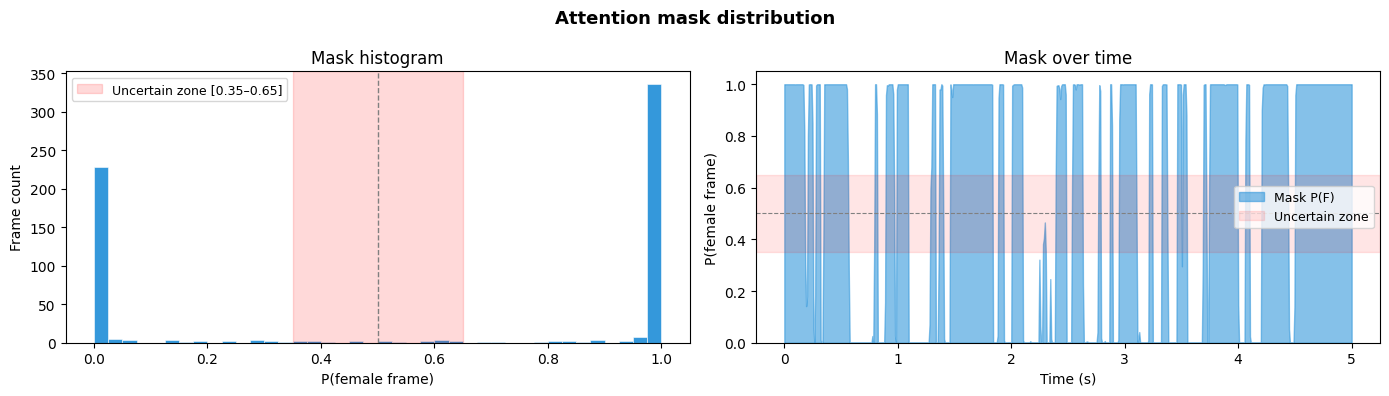

Uncertain frames (0.35–0.65): 17 / 626 = 2.7%


In [4]:
UNCERTAIN_LOW, UNCERTAIN_HIGH = 0.35, 0.65
n_uncertain = ((mask_aligned > UNCERTAIN_LOW) & (mask_aligned < UNCERTAIN_HIGH)).sum()
pct_uncertain = 100 * n_uncertain / n_frames

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Attention mask distribution", fontsize=13, fontweight="bold")

# Histogram
ax = axes[0]
ax.hist(mask_aligned, bins=40, color="#3498db", edgecolor="white", linewidth=0.4)
ax.axvspan(UNCERTAIN_LOW, UNCERTAIN_HIGH, alpha=0.15, color="red", label=f"Uncertain zone [{UNCERTAIN_LOW}–{UNCERTAIN_HIGH}]")
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("P(female frame)")
ax.set_ylabel("Frame count")
ax.set_title("Mask histogram")
ax.legend(fontsize=9)

# Time series
ax = axes[1]
frame_times = librosa.frames_to_time(np.arange(n_frames), sr=SR, hop_length=HOP_LENGTH)
ax.fill_between(frame_times, mask_aligned, alpha=0.6, color="#3498db", label="Mask P(F)")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.axhspan(UNCERTAIN_LOW, UNCERTAIN_HIGH, alpha=0.1, color="red", label="Uncertain zone")
ax.set_xlabel("Time (s)")
ax.set_ylabel("P(female frame)")
ax.set_title("Mask over time")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Uncertain frames ({UNCERTAIN_LOW}–{UNCERTAIN_HIGH}): {n_uncertain} / {n_frames} = {pct_uncertain:.1f}%")

## 4. IBM accuracy — is the classifier correct?

In [5]:
# Classifier prediction: mask > 0.5 → predicted female (0), else male (1)
pred_label = (mask_aligned <= 0.5).astype(int)   # 1 where classifier says M

accuracy      = (pred_label == ibm_aligned).mean()
acc_on_female = (pred_label[ibm_aligned == 0] == 0).mean()   # recall on F frames
acc_on_male   = (pred_label[ibm_aligned == 1] == 1).mean()   # recall on M frames

# Mean mask value on F-dominant vs M-dominant frames
mean_mask_on_female = mask_aligned[ibm_aligned == 0].mean()
mean_mask_on_male   = mask_aligned[ibm_aligned == 1].mean()

print(f"Overall IBM accuracy          : {accuracy:.3f} ({100*accuracy:.1f}%)")
print(f"Recall on F-dominant frames   : {acc_on_female:.3f} ({100*acc_on_female:.1f}%)")
print(f"Recall on M-dominant frames   : {acc_on_male:.3f} ({100*acc_on_male:.1f}%)")
print()
print(f"Mean mask on F-dominant frames: {mean_mask_on_female:.3f}  (ideal → 1.0)")
print(f"Mean mask on M-dominant frames: {mean_mask_on_male:.3f}  (ideal → 0.0)")

Overall IBM accuracy          : 0.679 (67.9%)
Recall on F-dominant frames   : 0.720 (72.0%)
Recall on M-dominant frames   : 0.617 (61.7%)

Mean mask on F-dominant frames: 0.717  (ideal → 1.0)
Mean mask on M-dominant frames: 0.386  (ideal → 0.0)


## 5. Confusion matrix

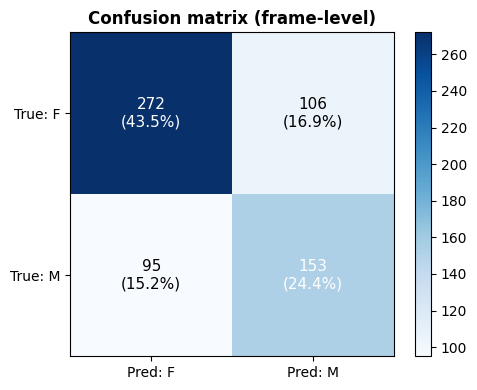

In [6]:
tp = ((pred_label == 0) & (ibm_aligned == 0)).sum()   # predicted F, actually F
fp = ((pred_label == 0) & (ibm_aligned == 1)).sum()   # predicted F, actually M
fn = ((pred_label == 1) & (ibm_aligned == 0)).sum()   # predicted M, actually F
tn = ((pred_label == 1) & (ibm_aligned == 1)).sum()   # predicted M, actually M

cm = np.array([[tp, fn], [fp, tn]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: F", "Pred: M"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["True: F", "True: M"])
ax.set_title("Confusion matrix (frame-level)", fontweight="bold")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]}\n({100*cm[i,j]/n_frames:.1f}%)",
                ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 6. Mask vs IBM — visual comparison over time

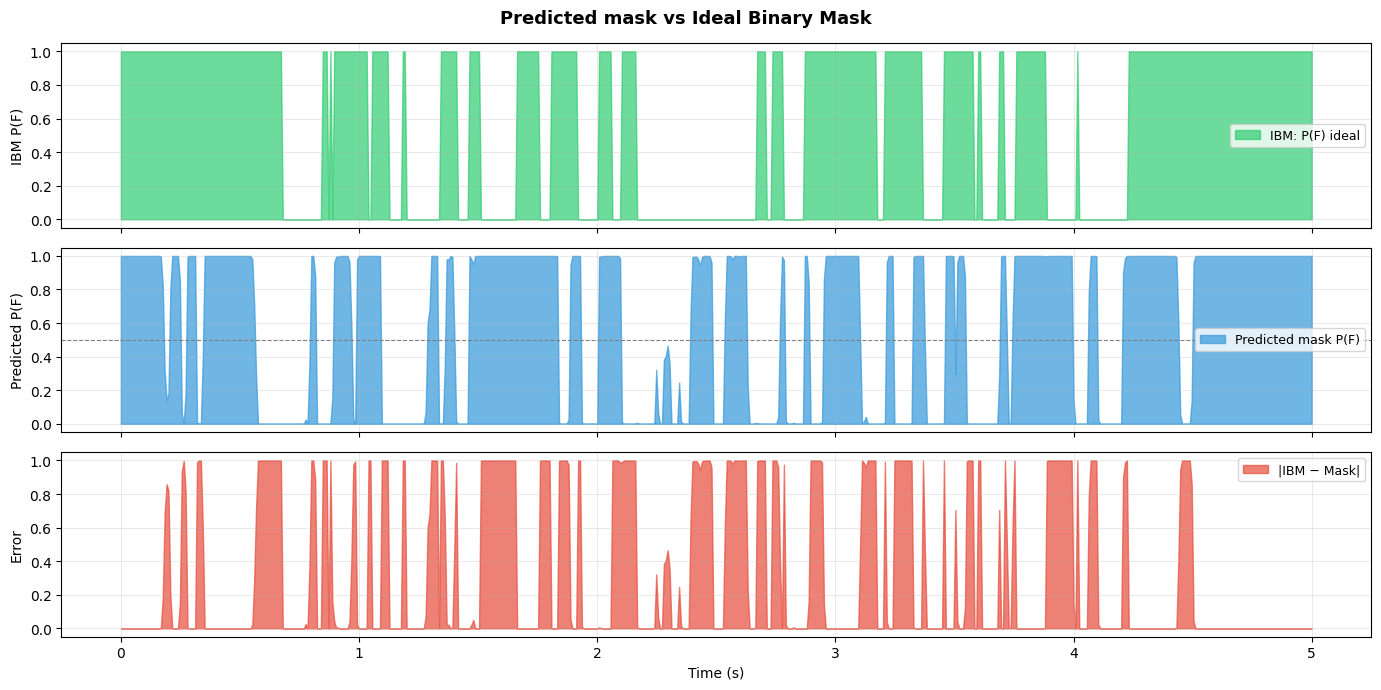

Mean absolute error (mask vs IBM): 0.324


In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
fig.suptitle("Predicted mask vs Ideal Binary Mask", fontsize=13, fontweight="bold")

# IBM (ground truth)
ax1.fill_between(frame_times, 1 - ibm_aligned, alpha=0.7, color="#2ecc71", label="IBM: P(F) ideal")
ax1.set_ylabel("IBM P(F)")
ax1.set_ylim(-0.05, 1.05)
ax1.legend(fontsize=9)
ax1.grid(True, linewidth=0.4, alpha=0.5)

# Predicted mask
ax2.fill_between(frame_times, mask_aligned, alpha=0.7, color="#3498db", label="Predicted mask P(F)")
ax2.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Predicted P(F)")
ax2.set_ylim(-0.05, 1.05)
ax2.legend(fontsize=9)
ax2.grid(True, linewidth=0.4, alpha=0.5)

# Error: where classifier disagrees with IBM
error = np.abs((1 - ibm_aligned) - mask_aligned)
ax3.fill_between(frame_times, error, alpha=0.7, color="#e74c3c", label="|IBM − Mask|")
ax3.set_ylabel("Error")
ax3.set_xlabel("Time (s)")
ax3.set_ylim(-0.05, 1.05)
ax3.legend(fontsize=9)
ax3.grid(True, linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Mean absolute error (mask vs IBM): {error.mean():.3f}")

## 7. Diagnosis summary

In [8]:
print("=" * 60)
print("  DIAGNOSIS SUMMARY")
print("=" * 60)
print()
print(f"  Uncertain frames (mask in [{UNCERTAIN_LOW}–{UNCERTAIN_HIGH}]): {pct_uncertain:.1f}%")
print(f"  Overall IBM accuracy                       : {100*accuracy:.1f}%")
print(f"  Recall on F-dominant frames                : {100*acc_on_female:.1f}%")
print(f"  Recall on M-dominant frames                : {100*acc_on_male:.1f}%")
print(f"  Mean mask on F frames (ideal 1.0)          : {mean_mask_on_female:.3f}")
print(f"  Mean mask on M frames (ideal 0.0)          : {mean_mask_on_male:.3f}")
print(f"  Mean absolute error vs IBM                 : {error.mean():.3f}")
print()

# Automatic verdict
if pct_uncertain > 40:
    cause = "CLASSIFIER — too many uncertain frames (>40%). The model cannot confidently distinguish M/F frames in the mixture."
elif accuracy < 0.65:
    cause = "CLASSIFIER — low IBM accuracy (<65%). The model is confident but systematically wrong on many frames."
elif mean_mask_on_female < 0.6 or mean_mask_on_male > 0.4:
    cause = "MASKING — classifier is reasonably accurate but the mask values lack contrast (F frames not high enough, M frames not low enough)."
else:
    cause = "MASKING STAGE — classifier output looks reasonable. The bottleneck is in the NMF/IRM application."

print(f"  Root cause: {cause}")
print()
print("=" * 60)

  DIAGNOSIS SUMMARY

  Uncertain frames (mask in [0.35–0.65]): 2.7%
  Overall IBM accuracy                       : 67.9%
  Recall on F-dominant frames                : 72.0%
  Recall on M-dominant frames                : 61.7%
  Mean mask on F frames (ideal 1.0)          : 0.717
  Mean mask on M frames (ideal 0.0)          : 0.386
  Mean absolute error vs IBM                 : 0.324

  Root cause: MASKING STAGE — classifier output looks reasonable. The bottleneck is in the NMF/IRM application.

